In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/ML/dementia_dataset.csv")

df

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,Nondemented,2,763,F,R,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


In [35]:
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


array([[<Axes: title={'center': 'Visit'}>,
        <Axes: title={'center': 'MR Delay'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'EDUC'}>,
        <Axes: title={'center': 'SES'}>,
        <Axes: title={'center': 'MMSE'}>],
       [<Axes: title={'center': 'CDR'}>,
        <Axes: title={'center': 'eTIV'}>,
        <Axes: title={'center': 'nWBV'}>],
       [<Axes: title={'center': 'ASF'}>, <Axes: >, <Axes: >]],
      dtype=object)

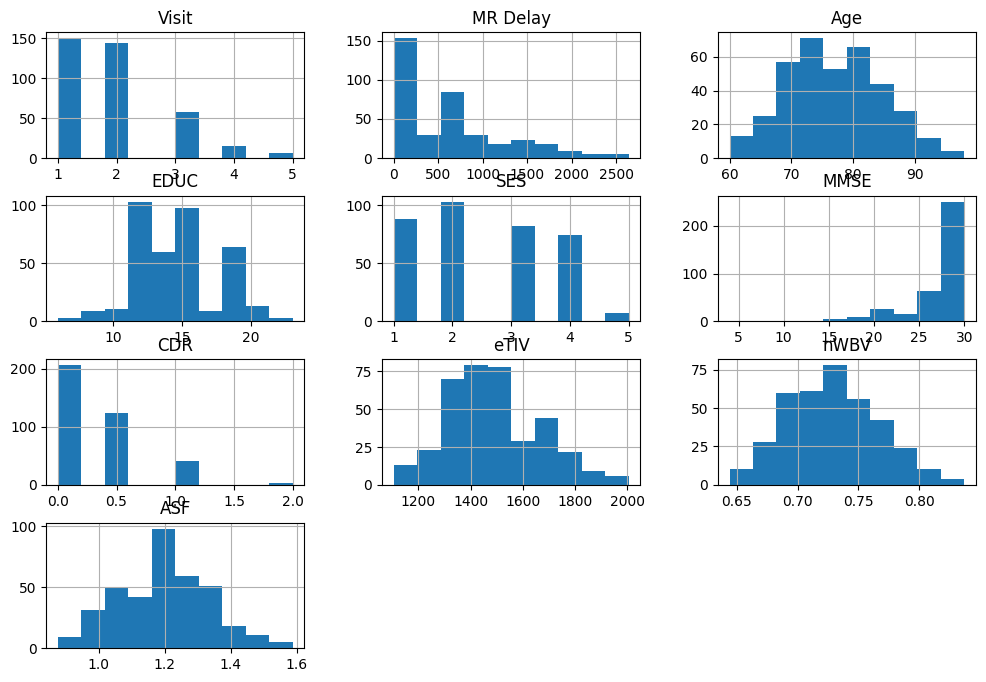

In [36]:
df.hist(figsize=(12,8))

<Axes: xlabel='Group'>

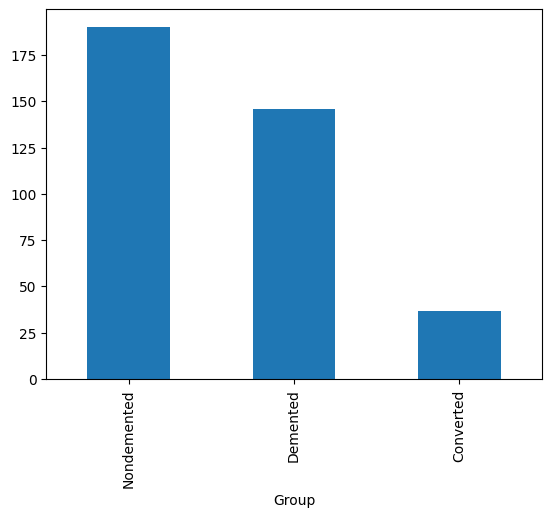

In [37]:
df["Group"].value_counts().plot(kind="bar")

<Axes: xlabel='M/F'>

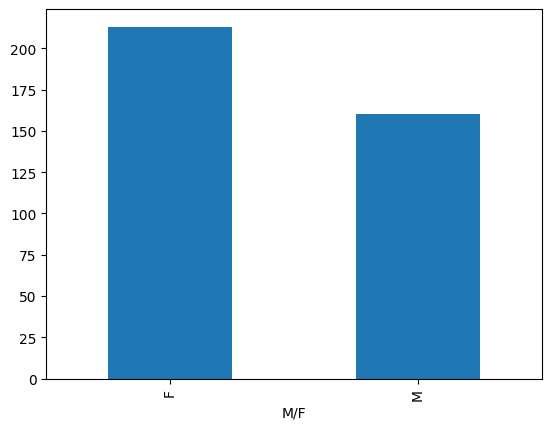

In [38]:
df["M/F"].value_counts().plot(kind="bar")

<Axes: xlabel='Hand'>

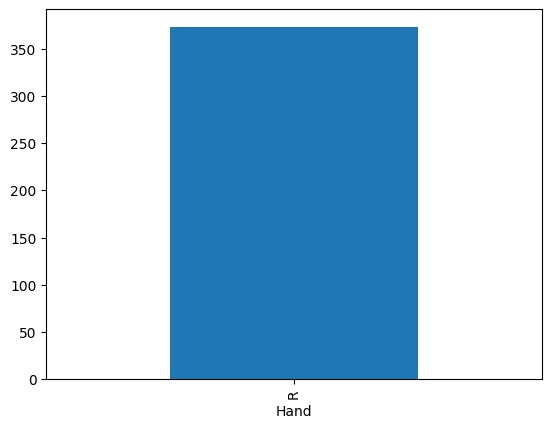

In [39]:
df["Hand"].value_counts().plot(kind="bar")

In [40]:
X = df.drop(columns = ["Subject ID", "MRI ID", "Group", "Hand"])

In [41]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
X["M/F"] = ordinal_encoder.fit_transform(df[["M/F"]])

In [42]:
X

,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,1,0,1.0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,2,457,1.0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,1,0,1.0,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,2,560,1.0,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,3,1895,1.0,80,12,NaN,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...
368,2,842,1.0,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,3,2297,1.0,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,1,0,0.0,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,2,763,0.0,63,13,2.0,30.0,0.0,1327,0.796,1.323


<Axes: >

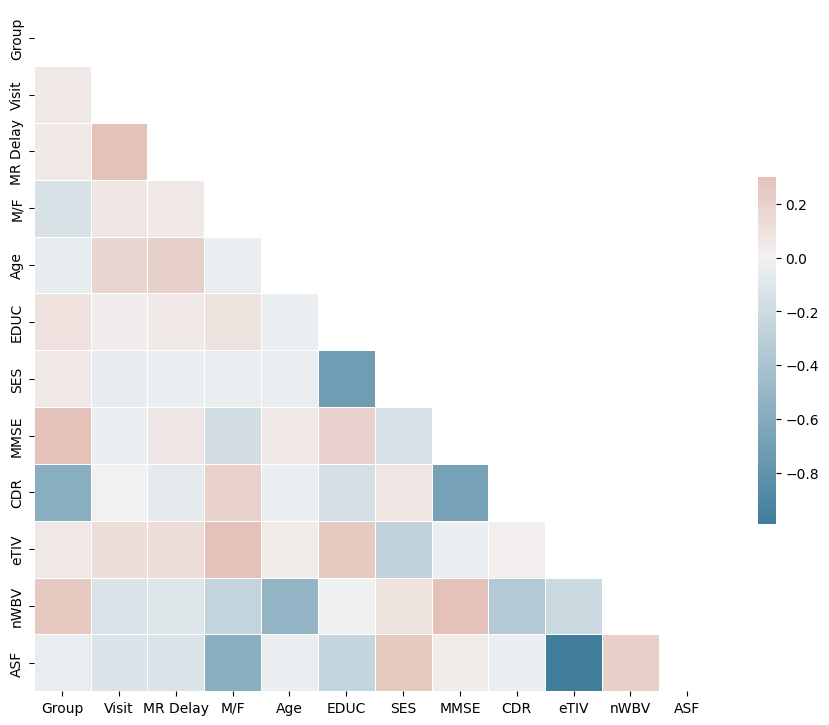

In [43]:
import seaborn as sns

X_corr = df.drop(columns = ["Subject ID", "MRI ID", "Hand"])
X_corr["Group"] = ordinal_encoder.fit_transform(df[["Group"]])
X_corr["M/F"] = ordinal_encoder.fit_transform(df[["M/F"]])
corr = X_corr.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr,mask=mask,cmap=cmap,vmax=.3,center=0,square=True, linewidth=.5,cbar_kws={"shrink": .5})

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# Create a working copy of df to avoid modifying the original dataframe
df_processed = df.copy()

# Initialize and fit the encoder for the 'M/F' column
gender_encoder = OrdinalEncoder()
df_processed["M/F"] = gender_encoder.fit_transform(df_processed[["M/F"]])

# Initialize and fit the encoder for the 'Group' column (target variable)
group_encoder = OrdinalEncoder()
df_processed["Group"] = group_encoder.fit_transform(df_processed[["Group"]])

# Assuming 'Group' is the target variable
X_data = df_processed.drop(columns=["Group","Subject ID", "MRI ID", "Hand"])
y_data = df_processed["Group"]

# Split the data into training and testing sets (80% train, 20% test)
train_df, test_df, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

display(train_df.head())
display(test_df.head())

,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
337,3,1695,1.0,81,16,3.0,30.0,0.0,1836,0.744,0.956
280,2,636,1.0,75,18,2.0,30.0,0.5,1651,0.737,1.063
311,3,1329,0.0,69,18,2.0,29.0,0.0,1202,0.770,1.461
166,1,0,1.0,69,16,2.0,28.0,0.0,1848,0.737,0.950
211,3,1752,0.0,82,11,4.0,30.0,0.0,1590,0.760,1.104


,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
353,3,1447,0.0,93,14,2.0,30.0,0.0,1488,0.735,1.179
212,1,0,0.0,71,18,2.0,30.0,0.0,1371,0.769,1.280
154,1,0,0.0,83,13,2.0,27.0,1.0,1391,0.705,1.262
194,1,0,0.0,83,12,2.0,28.0,0.0,1383,0.748,1.269
3,2,560,1.0,76,12,NaN,28.0,0.5,1738,0.713,1.010


In [45]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

numeric_columns = [
    "Age",
    "EDUC",
    "SES",
    "MMSE",
    "CDR",
    "eTIV",
    "nWBV",
    "ASF"
]

# Scale because KNN uses distances and these columns have different ranges
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_df[numeric_columns])
X_test_scaled = scaler.transform(test_df[numeric_columns])

# Learn neighbors using training data only
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

# Return to the columns' original scales
X_train_imputed = scaler.inverse_transform(X_train_imputed)
X_test_imputed = scaler.inverse_transform(X_test_imputed)

train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=numeric_columns,
    index=train_df.index
)

test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=numeric_columns,
    index=test_df.index
)

In [46]:
for col in numeric_columns:
    train_df[col] = train_imputed[col]
    test_df[col] = test_imputed[col]

In [47]:
train_df["SES"] = train_df["SES"].round().clip(1, 5).astype(int)
test_df["SES"] = test_df["SES"].round().clip(1, 5).astype(int)

In [48]:
print(train_df["SES"].isna().sum())
print(test_df["SES"].isna().sum())
print(train_df["SES"].value_counts().sort_index())

0
0
SES
1    75
2    81
3    74
4    62
5     6
Name: count, dtype: int64


In [49]:
train_df.dropna()

,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
337,3,1695,1.0,81.0,16.0,3,30.0,0.0,1836.0,0.744,0.956
280,2,636,1.0,75.0,18.0,2,30.0,0.5,1651.0,0.737,1.063
311,3,1329,0.0,69.0,18.0,2,29.0,0.0,1202.0,0.770,1.461
166,1,0,1.0,69.0,16.0,2,28.0,0.0,1848.0,0.737,0.950
211,3,1752,0.0,82.0,11.0,4,30.0,0.0,1590.0,0.760,1.104
...,...,...,...,...,...,...,...,...,...,...,...
86,1,0,0.0,72.0,12.0,4,26.0,0.5,1453.0,0.777,1.208
259,2,472,0.0,75.0,12.0,3,29.0,0.0,1338.0,0.747,1.312
83,3,1331,0.0,75.0,16.0,1,28.0,0.5,1314.0,0.760,1.335
291,2,665,0.0,71.0,16.0,3,28.0,0.0,1390.0,0.810,1.262


In [50]:
test_df.dropna()

,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
353,3,1447,0.0,93.0,14.0,2,30.0,0.0,1488.0,0.735,1.179
212,1,0,0.0,71.0,18.0,2,30.0,0.0,1371.0,0.769,1.280
154,1,0,0.0,83.0,13.0,2,27.0,1.0,1391.0,0.705,1.262
194,1,0,0.0,83.0,12.0,2,28.0,0.0,1383.0,0.748,1.269
3,2,560,1.0,76.0,12.0,3,28.0,0.5,1738.0,0.713,1.010
...,...,...,...,...,...,...,...,...,...,...,...
244,4,1927,1.0,78.0,20.0,2,29.0,0.0,1826.0,0.734,0.961
191,3,1345,1.0,76.0,18.0,2,30.0,0.0,1550.0,0.758,1.133
153,5,2386,1.0,86.0,17.0,1,30.0,0.0,1720.0,0.705,1.020
273,1,0,0.0,78.0,12.0,3,29.0,0.0,1475.0,0.731,1.190


In [51]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 353 to 51
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Visit     75 non-null     int64  
 1   MR Delay  75 non-null     int64  
 2   M/F       75 non-null     float64
 3   Age       75 non-null     float64
 4   EDUC      75 non-null     float64
 5   SES       75 non-null     int64  
 6   MMSE      75 non-null     float64
 7   CDR       75 non-null     float64
 8   eTIV      75 non-null     float64
 9   nWBV      75 non-null     float64
 10  ASF       75 non-null     float64
dtypes: float64(8), int64(3)
memory usage: 7.0 KB


In [52]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298 entries, 337 to 72
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Visit     298 non-null    int64  
 1   MR Delay  298 non-null    int64  
 2   M/F       298 non-null    float64
 3   Age       298 non-null    float64
 4   EDUC      298 non-null    float64
 5   SES       298 non-null    int64  
 6   MMSE      298 non-null    float64
 7   CDR       298 non-null    float64
 8   eTIV      298 non-null    float64
 9   nWBV      298 non-null    float64
 10  ASF       298 non-null    float64
dtypes: float64(8), int64(3)
memory usage: 27.9 KB


In [53]:
train_df

,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
337,3,1695,1.0,81.0,16.0,3,30.0,0.0,1836.0,0.744,0.956
280,2,636,1.0,75.0,18.0,2,30.0,0.5,1651.0,0.737,1.063
311,3,1329,0.0,69.0,18.0,2,29.0,0.0,1202.0,0.770,1.461
166,1,0,1.0,69.0,16.0,2,28.0,0.0,1848.0,0.737,0.950
211,3,1752,0.0,82.0,11.0,4,30.0,0.0,1590.0,0.760,1.104
...,...,...,...,...,...,...,...,...,...,...,...
86,1,0,0.0,72.0,12.0,4,26.0,0.5,1453.0,0.777,1.208
259,2,472,0.0,75.0,12.0,3,29.0,0.0,1338.0,0.747,1.312
83,3,1331,0.0,75.0,16.0,1,28.0,0.5,1314.0,0.760,1.335
291,2,665,0.0,71.0,16.0,3,28.0,0.0,1390.0,0.810,1.262


In [54]:
test_df

,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
353,3,1447,0.0,93.0,14.0,2,30.0,0.0,1488.0,0.735,1.179
212,1,0,0.0,71.0,18.0,2,30.0,0.0,1371.0,0.769,1.280
154,1,0,0.0,83.0,13.0,2,27.0,1.0,1391.0,0.705,1.262
194,1,0,0.0,83.0,12.0,2,28.0,0.0,1383.0,0.748,1.269
3,2,560,1.0,76.0,12.0,3,28.0,0.5,1738.0,0.713,1.010
...,...,...,...,...,...,...,...,...,...,...,...
244,4,1927,1.0,78.0,20.0,2,29.0,0.0,1826.0,0.734,0.961
191,3,1345,1.0,76.0,18.0,2,30.0,0.0,1550.0,0.758,1.133
153,5,2386,1.0,86.0,17.0,1,30.0,0.0,1720.0,0.705,1.020
273,1,0,0.0,78.0,12.0,3,29.0,0.0,1475.0,0.731,1.190


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_clf.fit(train_df, y_train)

# Make predictions on the test set
y_pred_rf = rf_clf.predict(test_df)

# Evaluate the classifier
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 0.9067

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.25      0.36         8
         1.0       0.97      0.97      0.97        29
         2.0       0.88      1.00      0.94        38

    accuracy                           0.91        75
   macro avg       0.84      0.74      0.76        75
weighted avg       0.89      0.91      0.89        75

